# 102 --- Historical Data Analysis

This notebook demonstrates how to fetch, analyze, and visualize
historical market data using `thetadatadx`. We cover:

1. End-of-day price charts
2. Daily return distributions
3. Intraday trade volume analysis
4. Bid-ask spread from quote data
5. Multi-symbol comparison

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from thetadatadx import Credentials, Config, ThetaDataDx

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

In [2]:
creds = Credentials.from_file("creds.txt")
tdx = ThetaDataDx(creds, Config.production())

## 1. AAPL End-of-Day --- Full Year

Fetch a full year of EOD data and plot the closing price.

In [ ]:
df = tdx.stock_history_eod("AAPL", "20230101", "20231231").to_pandas()

# Convert YYYYMMDD integer date to datetime
df["datetime"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d")
df = df.sort_values("datetime").reset_index(drop=True)

print(f"Trading days: {len(df)}")
df[["datetime", "open", "high", "low", "close", "volume"]].head()

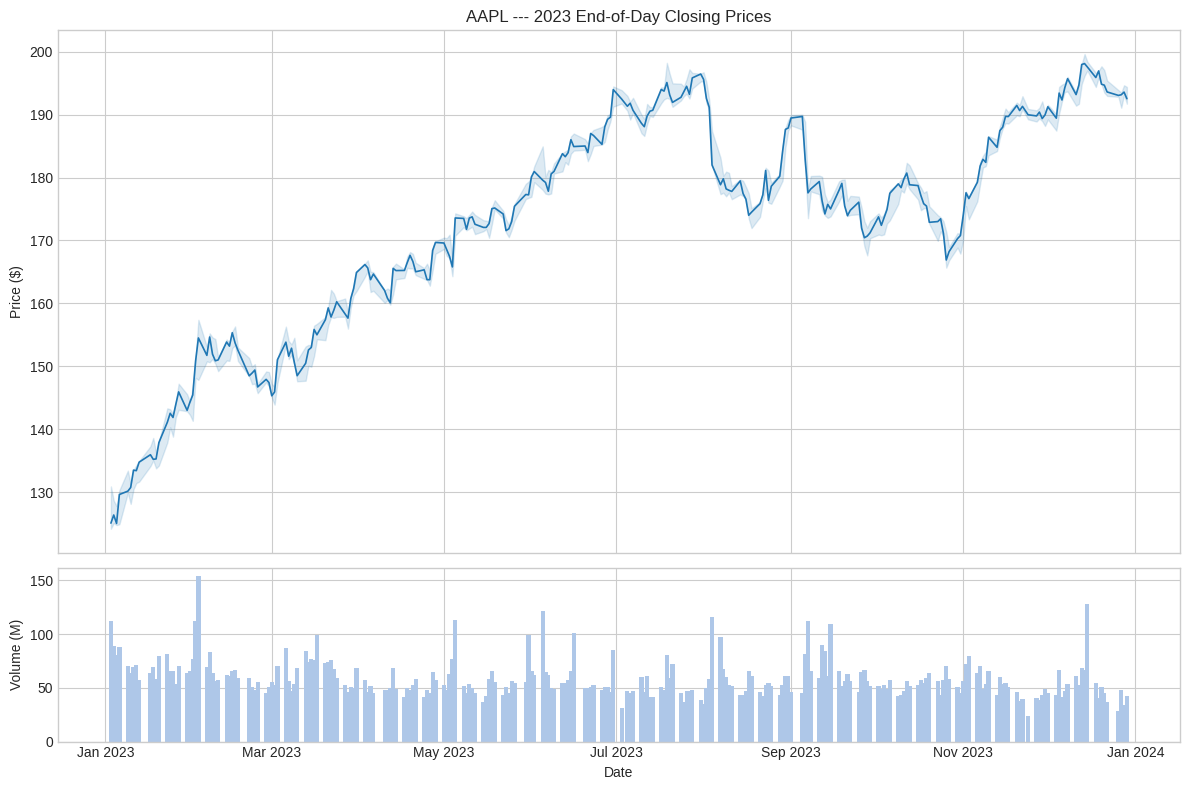

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(df["datetime"], df["close"], color="#1f77b4", linewidth=1.2)
ax1.fill_between(df["datetime"], df["low"], df["high"], alpha=0.15, color="#1f77b4")
ax1.set_ylabel("Price ($)")
ax1.set_title("AAPL --- 2023 End-of-Day Closing Prices")

ax2.bar(df["datetime"], df["volume"] / 1e6, width=1.5, color="#aec7e8", edgecolor="none")
ax2.set_ylabel("Volume (M)")
ax2.set_xlabel("Date")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.tight_layout()
plt.show()

## 2. Daily Returns Distribution

Compute log returns from close-to-close and plot the histogram.

Mean:     0.00173
Std Dev:  0.01255
Skew:     -0.0511
Kurtosis: 1.4694


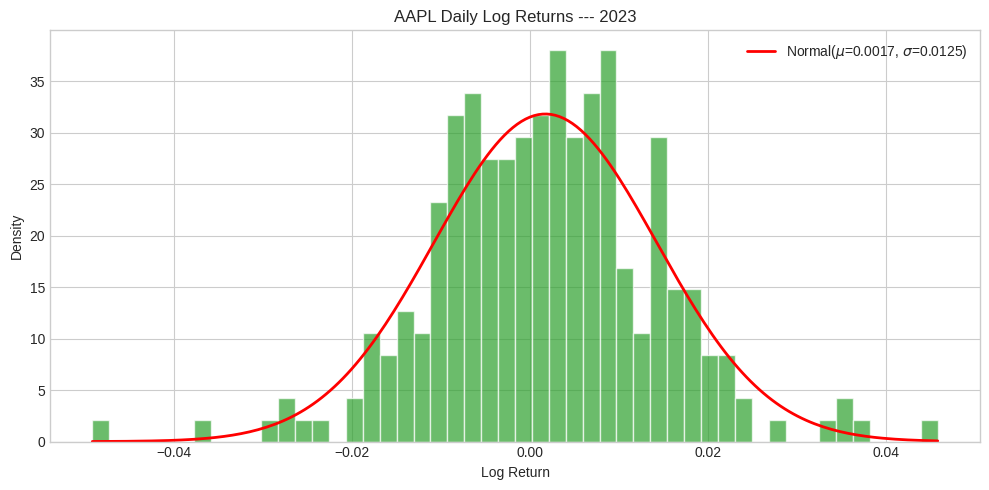

In [5]:
df["log_return"] = np.log(df["close"] / df["close"].shift(1))
returns = df["log_return"].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(returns, bins=50, density=True, alpha=0.7, color="#2ca02c", edgecolor="white")

# Overlay a normal distribution for comparison
mu, sigma = returns.mean(), returns.std()
x = np.linspace(returns.min(), returns.max(), 200)
ax.plot(x, (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2),
        color="red", linewidth=2, label=f"Normal($\\mu$={mu:.4f}, $\\sigma$={sigma:.4f})")

ax.set_xlabel("Log Return")
ax.set_ylabel("Density")
ax.set_title("AAPL Daily Log Returns --- 2023")
ax.legend()

print(f"Mean:     {mu:.5f}")
print(f"Std Dev:  {sigma:.5f}")
print(f"Skew:     {returns.skew():.4f}")
print(f"Kurtosis: {returns.kurtosis():.4f}")

plt.tight_layout()
plt.show()

## 3. Intraday Trades --- Volume Distribution

Fetch tick-level trade data for a single day and analyze how
volume distributes across the trading session.

In [ ]:
df_trades = tdx.stock_history_trade("AAPL", "20240315").to_pandas()

# Convert ms_of_day to a readable time
df_trades["time"] = pd.to_timedelta(df_trades["ms_of_day"], unit="ms")
df_trades["hour"] = df_trades["ms_of_day"] / 3_600_000

print(f"Total trades: {len(df_trades):,}")
print(f"Total volume: {df_trades['size'].sum():,}")
print(f"VWAP: ${(df_trades['price'] * df_trades['size']).sum() / df_trades['size'].sum():.2f}")
df_trades[["time", "price", "size", "exchange"]].head(10)

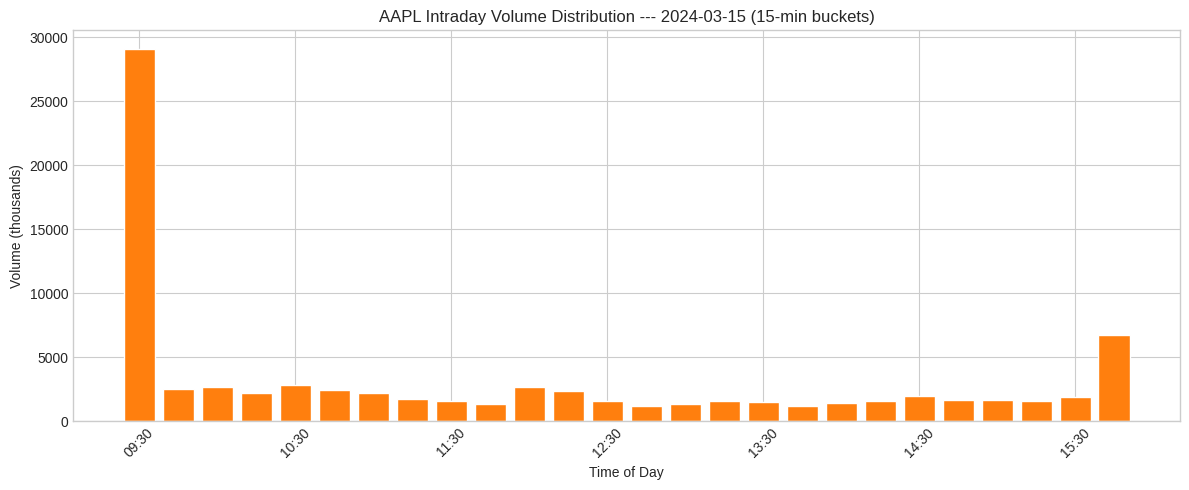

In [7]:
# Volume by 15-minute bucket
df_trades["bucket"] = (df_trades["ms_of_day"] // 900_000) * 900_000
vol_by_bucket = df_trades.groupby("bucket")["size"].sum().reset_index()
vol_by_bucket["time"] = pd.to_timedelta(vol_by_bucket["bucket"], unit="ms")

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(vol_by_bucket)), vol_by_bucket["size"] / 1e3,
       color="#ff7f0e", edgecolor="white", width=0.8)

# Label every 4th bar (hourly)
tick_positions = range(0, len(vol_by_bucket), 4)
tick_labels = [str(vol_by_bucket["time"].iloc[i])[7:12] for i in tick_positions]
ax.set_xticks(list(tick_positions))
ax.set_xticklabels(tick_labels, rotation=45)

ax.set_xlabel("Time of Day")
ax.set_ylabel("Volume (thousands)")
ax.set_title("AAPL Intraday Volume Distribution --- 2024-03-15 (15-min buckets)")

plt.tight_layout()
plt.show()

## 4. Quote Data --- Bid-Ask Spread Analysis

Fetch NBBO quotes sampled at 1-second intervals and compute
the bid-ask spread over the trading day.

In [ ]:
# interval = "1000" means 1-second NBBO snapshots
df_q = tdx.stock_history_quote("AAPL", "20240315", "1000").to_pandas()

# Filter to regular trading hours (9:30 - 16:00 ET)
rth_start = 9 * 3_600_000 + 30 * 60_000  # 9:30
rth_end = 16 * 3_600_000                  # 16:00
df_q = df_q[(df_q["ms_of_day"] >= rth_start) & (df_q["ms_of_day"] <= rth_end)].copy()

df_q["spread"] = df_q["ask"] - df_q["bid"]
df_q["mid"] = (df_q["ask"] + df_q["bid"]) / 2
df_q["spread_bps"] = (df_q["spread"] / df_q["mid"]) * 10_000
df_q["time"] = pd.to_timedelta(df_q["ms_of_day"], unit="ms")

print(f"Quotes: {len(df_q):,}")
print(f"Mean spread:   ${df_q['spread'].mean():.4f} ({df_q['spread_bps'].mean():.2f} bps)")
print(f"Median spread: ${df_q['spread'].median():.4f}")
print(f"Max spread:    ${df_q['spread'].max():.4f}")

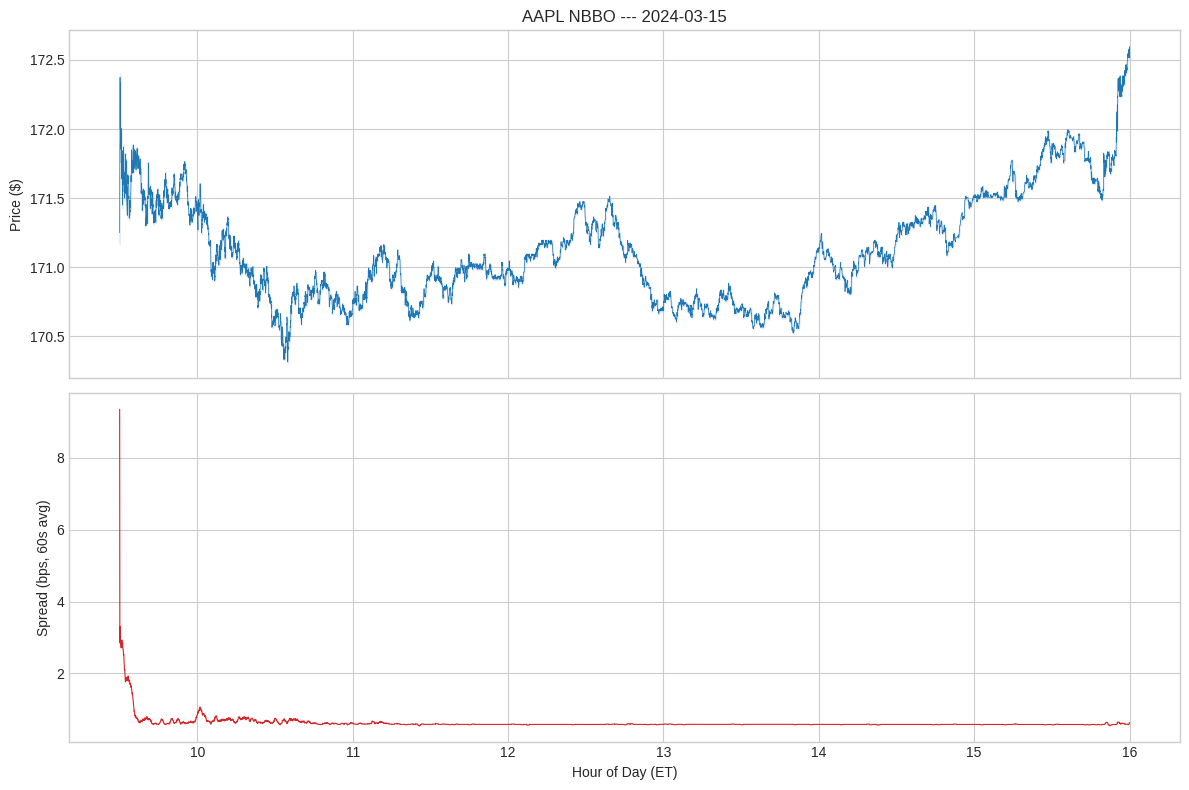

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

hours = df_q["ms_of_day"] / 3_600_000

ax1.plot(hours, df_q["mid"], linewidth=0.5, color="#1f77b4")
ax1.fill_between(hours, df_q["bid"], df_q["ask"], alpha=0.3, color="#aec7e8")
ax1.set_ylabel("Price ($)")
ax1.set_title("AAPL NBBO --- 2024-03-15")

# Rolling 60-second average spread in bps
ax2.plot(hours, df_q["spread_bps"].rolling(60, min_periods=1).mean(),
         linewidth=0.8, color="#d62728")
ax2.set_ylabel("Spread (bps, 60s avg)")
ax2.set_xlabel("Hour of Day (ET)")

plt.tight_layout()
plt.show()

## 5. Multi-Symbol Comparison

Compare AAPL, MSFT, and GOOGL side-by-side over the same period.

In [ ]:
tickers = ["AAPL", "MSFT", "GOOGL"]
dfs = {}

for ticker in tickers:
    tmp = tdx.stock_history_eod(ticker, "20230101", "20231231").to_pandas()
    tmp["datetime"] = pd.to_datetime(tmp["date"].astype(str), format="%Y%m%d")
    tmp = tmp.sort_values("datetime").reset_index(drop=True)
    dfs[ticker] = tmp
    print(f"{ticker}: {len(tmp)} days, close range ${tmp['close'].min():.2f} - ${tmp['close'].max():.2f}")

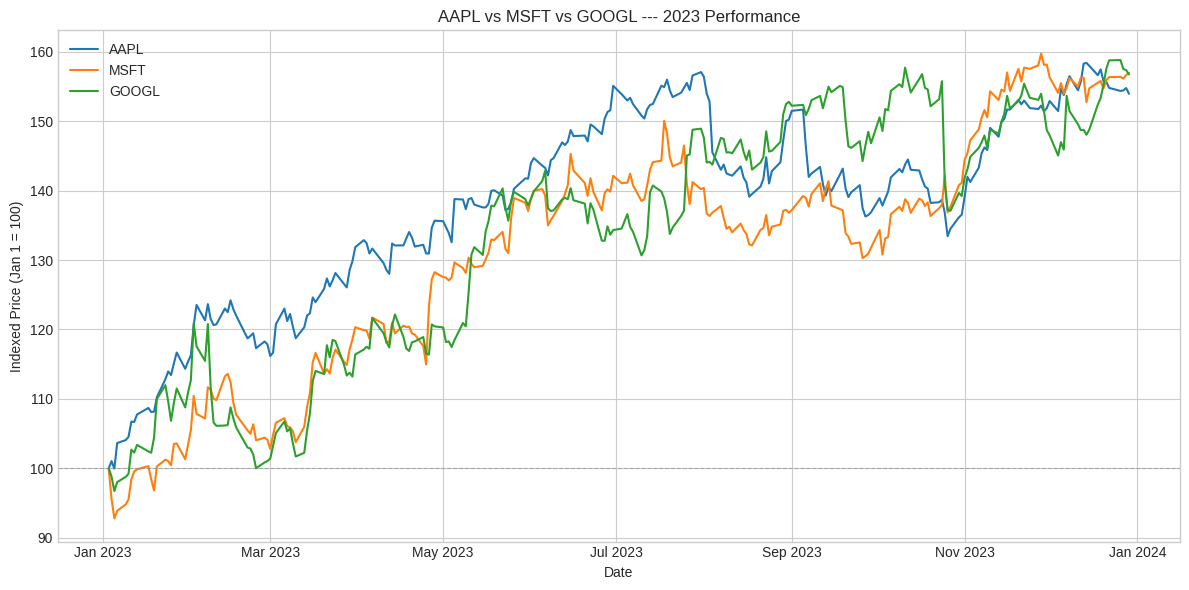

In [11]:
# Normalize to first-day close = 100 for comparison
fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for ticker, color in zip(tickers, colors):
    d = dfs[ticker]
    normalized = (d["close"] / d["close"].iloc[0]) * 100
    ax.plot(d["datetime"], normalized, label=ticker, color=color, linewidth=1.5)

ax.axhline(y=100, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_ylabel("Indexed Price (Jan 1 = 100)")
ax.set_xlabel("Date")
ax.set_title("AAPL vs MSFT vs GOOGL --- 2023 Performance")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.tight_layout()
plt.show()

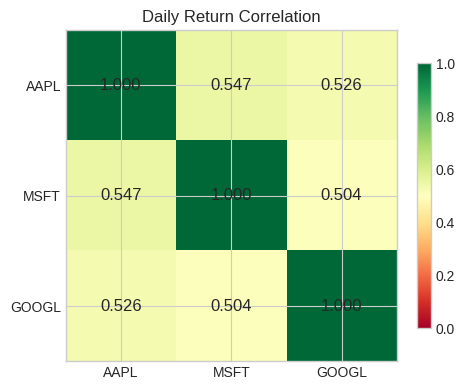

In [12]:
# Correlation matrix of daily returns
returns_df = pd.DataFrame()
for ticker in tickers:
    d = dfs[ticker]
    returns_df[ticker] = np.log(d["close"] / d["close"].shift(1))

corr = returns_df.corr()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr.values, cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))
ax.set_xticklabels(tickers)
ax.set_yticklabels(tickers)
for i in range(len(tickers)):
    for j in range(len(tickers)):
        ax.text(j, i, f"{corr.values[i, j]:.3f}", ha="center", va="center", fontsize=12)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Daily Return Correlation")

plt.tight_layout()
plt.show()

---

**Next:** [103 --- Building an Option Chain](103_options_chain.ipynb)